In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display plots in notebook
%matplotlib inline

In [5]:
df = pd.read_csv("C:/Users/keerthana/Downloads/house_prices.csv")
df.head()

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [7]:
print("Shape of dataset:", df.shape)

df.info()

Shape of dataset: (300, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


In [11]:
# check missing values
df.isnull().sum()
# check duplicates
df.duplicated().sum()

0

In [13]:
# remove duplicates
df = df.drop_duplicates()

# fill numeric missing values
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# fill categorical missing values
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()

C:\Users\keerthana\AppData\Local\Temp\ipykernel_20068\1377168490.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

In [15]:
# basic statistics
df.describe()
# mean
df.mean(numeric_only=True)
# median
df.median(numeric_only=True)

Area             2738.0
Bedrooms            3.0
Bathrooms           2.0
Age                25.5
Price        22365000.0
dtype: float64

In [17]:
corr = df.corr(numeric_only=True)

corr

,Area,Bedrooms,Bathrooms,Age,Price
Area,1.000000,-0.004218,-0.025524,-0.083118,0.796287
Bedrooms,-0.004218,1.000000,-0.043912,-0.032444,0.202458
Bathrooms,-0.025524,-0.043912,1.000000,0.118367,-0.030279
Age,-0.083118,-0.032444,0.118367,1.000000,-0.130781
Price,0.796287,0.202458,-0.030279,-0.130781,1.000000


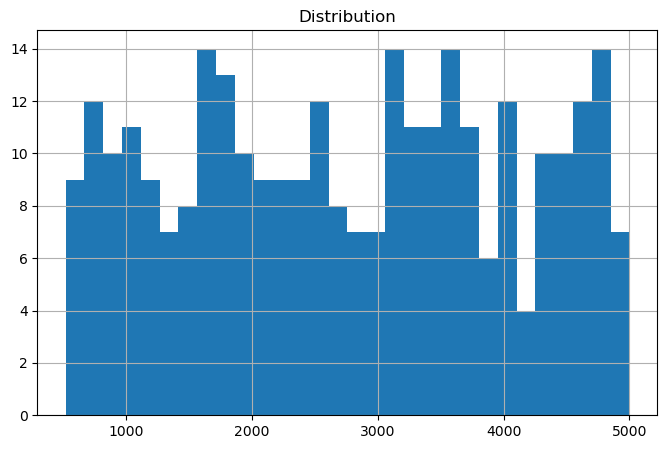

In [19]:
plt.figure(figsize=(8,5))
df[numeric_cols[0]].hist(bins=30)
plt.title("Distribution")
plt.show()

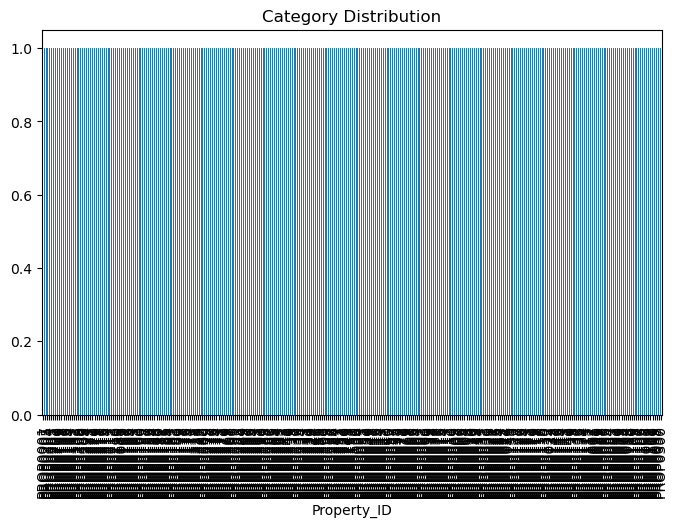

In [21]:
df[categorical_cols[0]].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Category Distribution")
plt.show()


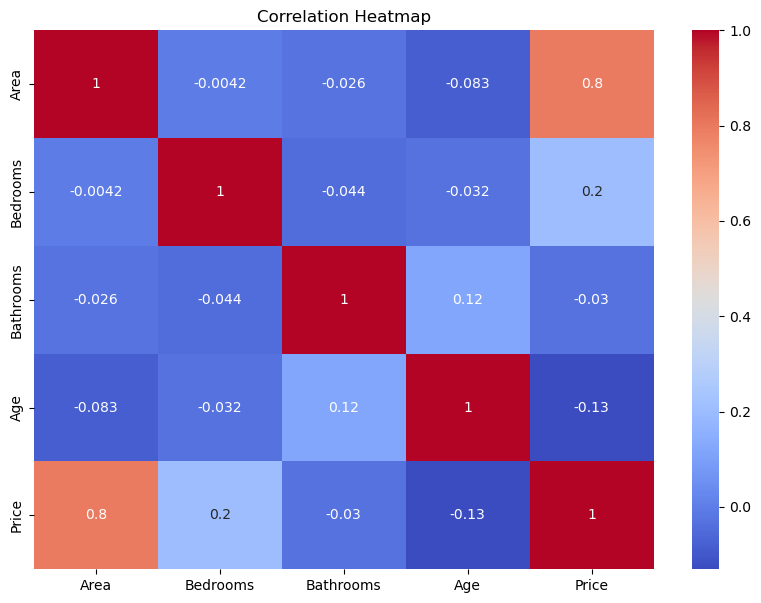

In [23]:
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [35]:
print("Average value:", df[numeric_cols[0]].mean())

print("Median value:", df[numeric_cols[0]].median())

print("Most common category:", df[categorical_cols[0]].value_counts().idxmax())

Average value: 2759.7
Median value: 2738.0
Most common category: PROP0001


In [37]:
df.to_csv("cleaned_data.csv", index=False)